# A Breeze tutorial: thermal bubbles to cloudy hills

Documentation for Breeze is available at
[numericalearth.github.io/BreezeDocumentation](https://numericalearth.github.io/BreezeDocumentation/dev/).

This tutorial introduces Breeze using four experiments:

| Part | What's new                              | Dynamics                    |
|:----:|-----------------------------------------|-----------------------------|
| I    | Dry thermal bubble                      | anelastic                   |
| II   | Forced convection over a warm surface   | anelastic                   |
| III  | Forced convection over a hill           | split-explicit compressible |
| IV   | Cloudy, hilly convection                | split-explicit compressible |

## Environment management

We begin by instantiating the environment:

In [69]:
using Pkg
Pkg.instantiate()

and then we can get onto to building the environment,

In [70]:
using Breeze
using Oceananigans: Oceananigans
using Oceananigans.Units
using Printf
using Random
using CairoMakie
using CUDA

Print the environment status *after* the `using` statements: only then can
`Pkg.status` flag a package whose loaded version differs from the resolved one
(shown as `[loaded: …]`). If you see that, restart the kernel — Julia can't
hot-swap an already-loaded package.

In [71]:
Pkg.status()

arch = GPU()
Oceananigans.defaults.FloatType = Float32

Status `~/ondemand/BjerknesWorkshop/tutorials/day2/Project.toml`
  [660aa2fb] Breeze v0.6.0
  [179af706] CFTime v0.2.10
  [052768ef] CUDA v6.2.0
  [13f3f980] CairoMakie v0.15.11
  [6ba0ff68] ClimaSeaIce v0.5.6
⌃ [6a9e3e04] CloudMicrophysics v0.35.0
  [cd43e856] CopernicusMarine v0.1.2
  [db073c08] GeoMakie v0.7.16
  [da04e1cc] MPI v0.20.26
  [904d977b] NumericalEarth v0.5.6 `https://github.com/NumericalEarth/NumericalEarth.jl#glw/support-breeze-0.6`
⌃ [9e8cae18] Oceananigans v0.110.1
  [d496a93d] SeawaterPolynomials v0.3.10
  [10745b16] Statistics v1.11.1
  [ade2ca70] Dates v1.11.0
  [de0858da] Printf v1.11.0
  [9a3f8284] Random v1.11.0
Info Packages marked with ⌃ have new versions available and may be upgradable.


Float32

A small helper that base64-embeds a finished `.mp4` in an HTML5 `<video>` tag,
so the animation plays inline in the notebook (no external file serving needed).

In [72]:
using Base64

mp4_html(path) = HTML(string("<video autoplay loop muted playsinline controls ",
                             "src=\"data:video/mp4;base64,", base64encode(read(path)),
                             "\" style=\"max-width:100%\"></video>"))

mp4_html (generic function with 1 method)

## The shared grid and background atmosphere

A single vertical slice serves every part: periodic in `x`, `Flat` in `y`. Two-
dimensional dynamics are a cartoon — no vortex stretching — but cheap to run and
rich enough to show what we are after.

In [73]:
Lx, Lz = 24kilometers, 8kilometers
Nx, Nz = 384, 160

grid = RectilinearGrid(arch;
                       size = (Nx, Nz),
                       halo = (5, 5),
                       x = (-Lx/2, Lx/2),
                       z = (0, Lz),
                       topology = (Periodic, Flat, Bounded))

384×1×160 RectilinearGrid{Float32, Periodic, Flat, Bounded} on CUDAGPU with 5×0×5 halo
├── Periodic x ∈ [-12000.0, 12000.0) regularly spaced with Δx=62.5
├── Flat y                           
└── Bounded  z ∈ [0.0, 8000.0]       regularly spaced with Δz=50.0

## The anelastic approximation and the reference state

The first three parts use **anelastic** dynamics. The atmosphere is compressible,
but sound waves are energetically irrelevant to convection and would force a tiny
time step, so the anelastic approximation filters them: each field splits into a
static, horizontally-uniform **reference profile** plus a small
**perturbation** (prime),

$$
ρ = ρᵣ(z) + ρ', \qquad p = pᵣ(z) + p', \qquad |ρ'| \ll ρᵣ ,
$$

with the reference state in hydrostatic balance, $dpᵣ/dz = -ρᵣ g$. Mass
conservation reads

$$
\frac{∂ρ}{∂t} + ∇·(ρ \, 𝐮) = 0 ,
$$

and dropping $∂ρ'/∂t$ — which is what removes the acoustic modes — leaves the
**anelastic constraint**

$$
∇·(ρᵣ \, 𝐮) = 0 ,
$$

while $p'$ is then diagnostic, from an elliptic solve enforcing that constraint.

The reference column is fixed by the **reference potential temperature**: with a
surface pressure, hydrostatic balance and the ideal-gas law then close $pᵣ(z)$,
$Tᵣ(z)$, and the density $ρᵣ(z)$. For the first two parts we take a *neutral*
atmosphere — a constant reference potential temperature — and introduce
stratification only at the hill in Part III. Advection is WENO with no closure.

In [74]:
θ₀ = 290     # K, reference potential temperature

reference_state = ReferenceState(grid; potential_temperature = θ₀)
dynamics = AnelasticDynamics(reference_state)
advection = WENO(order = 9)

model = AtmosphereModel(grid; dynamics, advection)

AtmosphereModel{GPU, RectilinearGrid}(time = 0 seconds, iteration = 0)
├── grid: 384×1×160 RectilinearGrid{Float32, Periodic, Flat, Bounded} on CUDAGPU with 5×0×5 halo
├── dynamics: AnelasticDynamics(p₀=101325.0, θ₀=290.0)
├── formulation: LiquidIcePotentialTemperatureFormulation
├── thermodynamic_constants: ThermodynamicConstants{Float32}
├── timestepper: SSPRungeKutta3
├── advection scheme: 
│   ├── momentum: WENO{5, Float32, Oceananigans.Utils.BackendOptimizedDivision}(order=9)
│   ├── ρθ: WENO{5, Float32, Oceananigans.Utils.BackendOptimizedDivision}(order=9)
│   └── ρqᵛ: WENO{5, Float32, Oceananigans.Utils.BackendOptimizedDivision}(order=9)
├── forcing: @NamedTuple{ρu::Returns{Float32}, ρv::Returns{Float32}, ρw::Returns{Float32}, ρθ::Returns{Float32}, ρqᵛ::Returns{Float32}, ρe::Returns{Float32}}
├── tracers: ()
├── coriolis: Nothing
└── microphysics: Nothing

Notice that `AtmosphereModel` solves the governing equations in **conservative
(flux) form**: the prognostic variables are the *densities* of momentum, heat, and
moisture — $ρ𝐮$, $ρθ$, $ρqᵛ$, $ρe$ — rather than the velocities and
potential temperature themselves. "Flux form" means a tracer is advanced as the
divergence of a flux, not by an advective (material) derivative. The two are equal:
expand the flux-form tendency with the product rule and collect terms,

$$
\frac{∂(ρθ)}{∂t} + ∇·(ρ \, 𝐮 \, θ)
  = ρ \left( \frac{∂θ}{∂t} + 𝐮·∇θ \right)
  + θ \underbrace{\left( \frac{∂ρ}{∂t} + ∇·(ρ \, 𝐮) \right)}_{=\,0} ,
$$

and the second group vanishes by **mass conservation**. So the conservative tendency
$∂(ρθ)/∂t + ∇·(ρ𝐮θ)$ is *identical* to the advective tendency
$ρ(∂θ/∂t + 𝐮·∇θ)$ — but advancing $ρθ$ through the flux $∇·(ρ𝐮θ)$ conserves
total heat exactly (up to boundary fluxes), which is why the model carries $ρθ$ and
its siblings. This is visible in the printed summary above, where the advected
quantities are listed as `ρθ` and `ρqᵛ` and the forcing entries act on `ρu`, `ρv`,
`ρw`, `ρθ`, `ρqᵛ`, and `ρe`. Diagnostics such as
`liquid_ice_potential_temperature(model)` recover the familiar primitive variables
(e.g. $θ = ρθ / ρ$) on demand.

For the full conservative-form governing equations and the details of the anelastic
approximation, see the
[anelastic dynamics](https://numericalearth.github.io/BreezeDocumentation/dev/anelastic_dynamics/)
page of the Breeze documentation.

## Part I — a dry thermal bubble

A warm perturbation $θ' = θ - θ₀$ feels a buoyancy

$$
b = -g \, \frac{ρ'}{ρᵣ} = g \, \frac{θ'}{θ₀}
$$

(exact in the anelastic system, where buoyancy is evaluated at the reference
pressure so $p'$ drops out): warm air rises, which is why we plot $θ'$.

The "hello, world" of atmospheric dynamics: a warm blob released at rest in a
neutral atmosphere. Being buoyant it rises, rolling up into the classic mushroom
vortex pair. We paint the warmth on as a smooth cone.

In [75]:
Δθ = 2              # K, bubble amplitude
r₀ = 1.5kilometers  # bubble radius
z₀ = 2kilometers    # release height

θ_bubble(x, z) = θ₀ + Δθ * max(0, 1 - sqrt(x^2 + (z - z₀)^2) / r₀)
set!(model, θ=θ_bubble)

Let's visualize the initial condition:

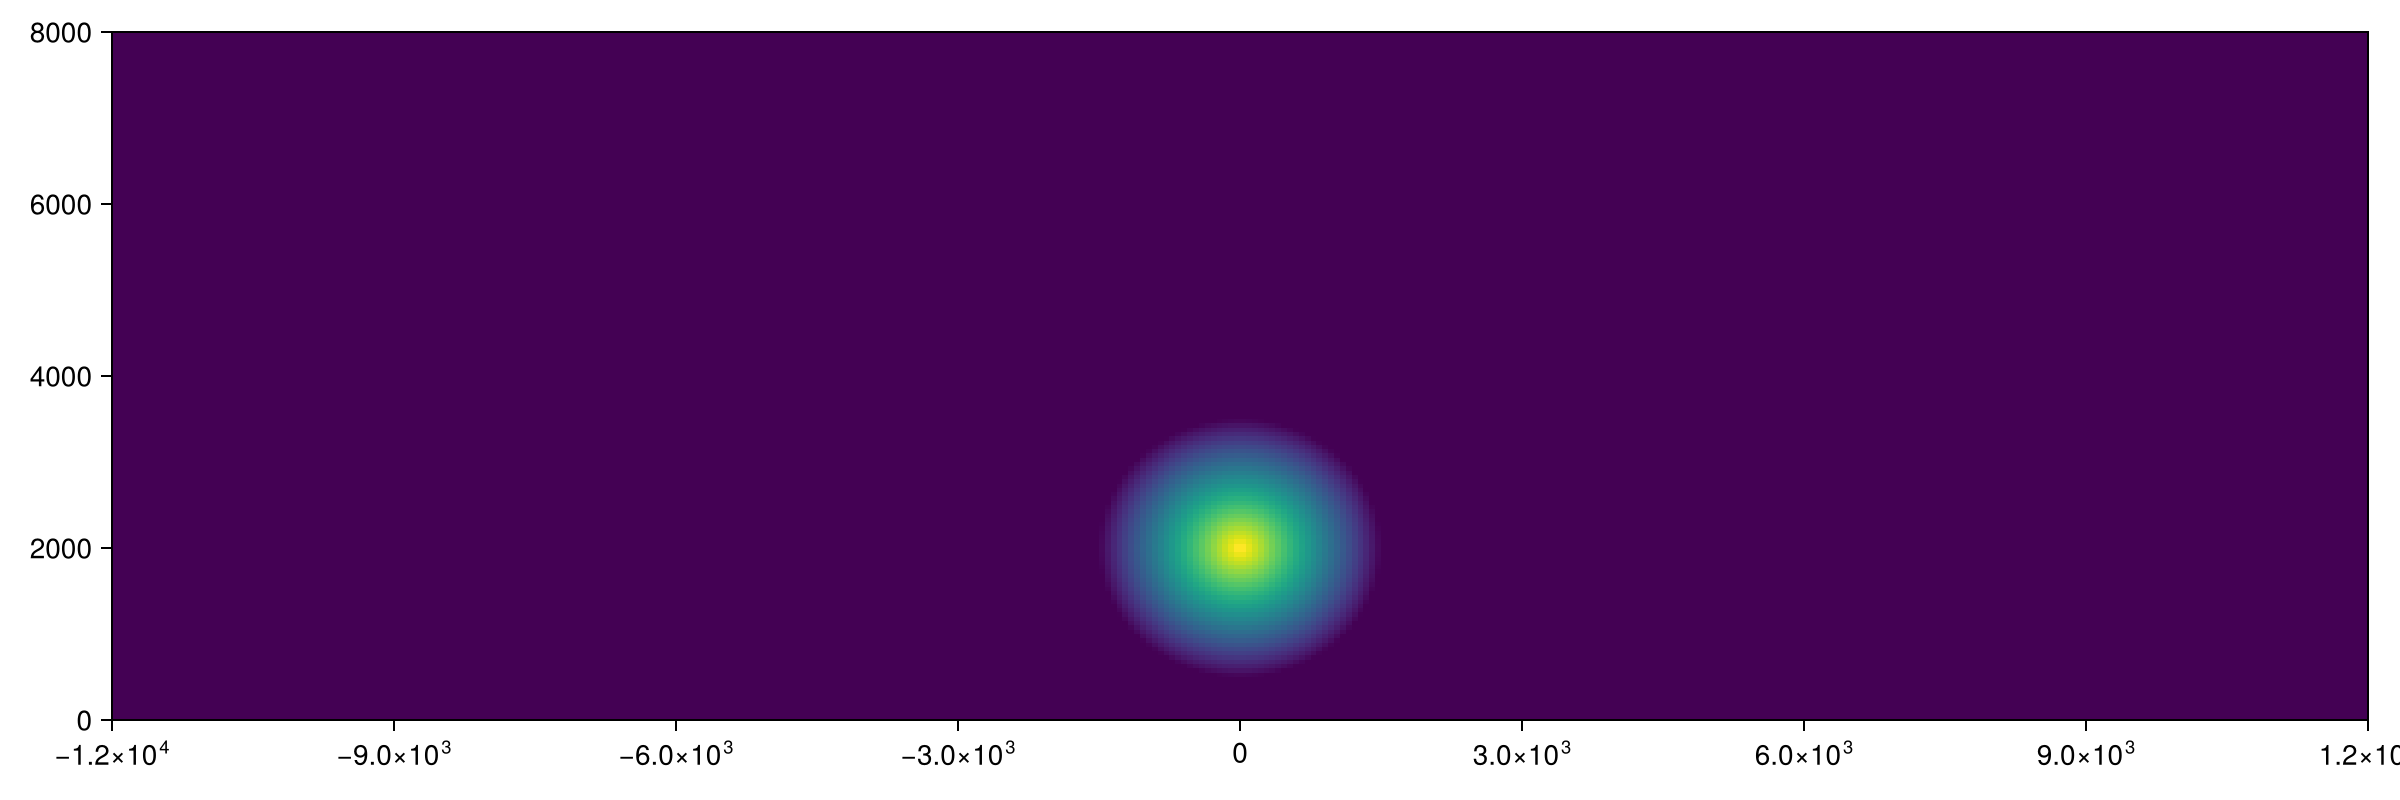

CairoMakie.Screen{IMAGE}


In [76]:
fig = Figure(size=(1200, 400), aspect=3)
ax = Axis(fig[1, 1])
heatmap!(ax, liquid_ice_potential_temperature(model))
display(fig)

A CFL wizard adapts the time step as the bubble accelerates, and a progress
callback logs the march periodically.

In [77]:
simulation = Simulation(model; Δt=1, stop_time=25minutes)
conjure_time_step_wizard!(simulation, cfl=0.7)

function progress(sim)
    @info @sprintf("thermal bubble | iter: %d, t: %s, Δt: %s, max|w|: %.2e m s⁻¹",
                   iteration(sim), prettytime(sim), prettytime(sim.Δt),
                   maximum(abs, sim.model.velocities.w))
    return nothing
end

add_callback!(simulation, progress, IterationInterval(200))

We save the potential-temperature perturbation $θ' = θ - θ₀$ and the velocities.

In [78]:
θ = liquid_ice_potential_temperature(model)
θ′ = θ - θ₀
outputs = (; θ′, model.velocities...)

bubble_ow = JLD2Writer(model, outputs;
                       filename = "thermal_bubble.jld2",
                       schedule = TimeInterval(1minute),
                       overwrite_existing = true)

simulation.output_writers[:fields] = bubble_ow

JLD2Writer scheduled on TimeInterval(1 minute):
├── filepath: thermal_bubble.jld2
├── 4 outputs: (θ′, u, v, w)
├── array_type: Array{Float32}
├── including: [:thermodynamic_constants]
├── file_splitting: NoFileSplitting
└── file size: 0 bytes (file not yet created)

Now we are ready to run the simulation,

In [79]:
run!(simulation)

[ Info: Initializing simulation...
[ Info: thermal bubble | iter: 0, t: 0 seconds, Δt: 1.100 seconds, max|w|: 0.00e+00 m s⁻¹
[ Info:     ... simulation initialization complete (2.365 seconds)
[ Info: Executing initial time step...
[ Info:     ... initial time step complete (4.541 ms).
[ Info: thermal bubble | iter: 200, t: 8.766 minutes, Δt: 3.326 seconds, max|w|: 1.05e+01 m s⁻¹
[ Info: thermal bubble | iter: 400, t: 16.663 minutes, Δt: 2.070 seconds, max|w|: 1.35e+01 m s⁻¹
[ Info: thermal bubble | iter: 600, t: 23.851 minutes, Δt: 2.386 seconds, max|w|: 1.05e+01 m s⁻¹
[ Info: Simulation is stopping after running for 5.377 seconds.
[ Info: Simulation time 25 minutes equals or exceeds stop time 25 minutes.


### The movie

Replay every saved frame as a heatmap of $θ'$.

In [80]:
θ′_ts = FieldTimeSeries("thermal_bubble.jld2", "θ′")
Nt = length(θ′_ts)

fig = Figure(size=(1200, 400), aspect=3)
ax = Axis(fig[1, 1])

n = Observable(1)
θ′n = @lift θ′_ts[$n]
heatmap!(ax, θ′n)

CairoMakie.record(fig, "thermal_bubble.mp4", 1:Nt; framerate = 24, compression = 28) do nn
    @info "Drawing frame $nn of $Nt..."
    n[] = nn
end

mp4_html("thermal_bubble.mp4")

[ Info: Drawing frame 1 of 26...
[ Info: Drawing frame 2 of 26...
[ Info: Drawing frame 3 of 26...
[ Info: Drawing frame 4 of 26...
[ Info: Drawing frame 5 of 26...
[ Info: Drawing frame 6 of 26...
[ Info: Drawing frame 7 of 26...
[ Info: Drawing frame 8 of 26...
[ Info: Drawing frame 9 of 26...
[ Info: Drawing frame 10 of 26...
[ Info: Drawing frame 11 of 26...
[ Info: Drawing frame 12 of 26...
[ Info: Drawing frame 13 of 26...
[ Info: Drawing frame 14 of 26...
[ Info: Drawing frame 15 of 26...
[ Info: Drawing frame 16 of 26...
[ Info: Drawing frame 17 of 26...
[ Info: Drawing frame 18 of 26...
[ Info: Drawing frame 19 of 26...
[ Info: Drawing frame 20 of 26...
[ Info: Drawing frame 21 of 26...
[ Info: Drawing frame 22 of 26...
[ Info: Drawing frame 23 of 26...
[ Info: Drawing frame 24 of 26...
[ Info: Drawing frame 25 of 26...
[ Info: Drawing frame 26 of 26...


HTML{String}("<video autoplay loop muted playsinline controls src=\"data:video/mp4;base64,AAAAIGZ0eXBpc29tAAACAGlzb21pc28yYXZjMW1wNDEAAAAIZnJlZQAA5D1tZGF0AAACsAYF//+s3EXpvebZSLeWLNgg2SPu73gyNjQgLSBjb3JlIDE2NCByMzIwM00gNTJmNzY5NCAtIEguMjY0L01QRUctNCBBVkMgY29kZWMgLSBDb3B5bGVmdCAyMDAzLTIwMjQgLSBodHRwOi8vd3d3LnZpZGVvbGFuLm9yZy94MjY0Lmh0bWwgLSBvcHRpb25zOiBjYWJhYz0xIHJlZj01IGRlYmxvY2s9MTowOjAgYW5hbHlzZT0weDM6MHgxMTMgbWU9aGV4IHN1Ym1lPTggcHN5PTEgcHN5X3JkPTEuMDA6MC4wMCBtaXhlZF9yZWY9MSBtZV9yYW5nZT0xNiBjaHJvbWFfbWU9MSB0cmVsbGlzPTIgOHg4ZGN0PTEgY3FtPTAgZGVhZHpvbmU9MjEsMTEgZmFzdF9wc2tpcD0xIGNocm9tYV9xcF9vZmZzZXQ9LTIgdGhyZWFkcz0yNSBsb29rYWhlYWRfdGhyZWFkcz00IHNsaWNlZF90aHJlYWRzPTAgbnI9MCBkZWNpbWF0ZT0xIGludGVybGFjZWQ9MCBibHVyYXlfY29tcGF0PTAgY29uc3RyYWluZWRfaW50cmE9MCBiZnJhbWVzPTMgYl9weXJhbWlkPTIgYl9hZGFwdD0xIGJfYmlhcz0wIGRpcmVjdD0zIHdlaWdodGI9MSBvcGVuX2dvcD0wIHdlaWdodHA9MiBrZXlpbnQ9MjUwIGtleWludF9taW49MjQgc2NlbmVjdXQ9NDAgaW50cmFfcmVmcmVzaD0wIHJjX2xvb2thaGVhZD01MCByYz1jcmYgbWJ0cmVlPTEgY3JmPTI4LjAgcWNvbXA9MC42MCBxcG1pbj0wIHFwbWF4PTY5IHFwc3RlcD00IGlwX3JhdGlvPTEuNDAgYXE9MToxLjAwAIAAACPUZYiEADv//vWxfApqyfMxm4aowkYr8KnXsXwE/x8AAAMAAAMAAAMAAAMAAAMAEVurwONH4gXJXU0+ic1kO/fmoZ77upIv14LZellhhJMeDHcEJjgZ8CL9UBpG9CBjrCVxyTX8KMs79yPvPi+Xyd7mlrKacVaA6MUlLtEOaD6neCDJmYPXVlPgPiNq/C0Q2pMyeoYRXuD0eCWLYI0NrKVR5kLDKM+snqlYydB/QSEGd6cIggD1RIGQHgKsFqqzlhuwpG7M1IIiAs92HyJu3VGq6TyudPEqO7RfQa+WpcJ39dzHGYYvXsXpy9B5G4SzcwwnVfMKz+8YpZvGTn48hBbm7LoTPxyGo+oQX9ESo1jEfrugw3+3zeHPseoH7s+Fn1Y1hoGQowDIgnYAO0QRMhnkhGBFQtoY+pVK4zwYnOJoQXyJWH1bBh/Kli6j1KmNZgIq2fLqMvl4toAAAAMAABLpXKdYUoDZYehihvcPdIsopRKizTkYpHdpSyDtlurgFWVQxaMH/7A+5kIyrmaLpJ/da1ovtDRJyQO/400xhiM3ITufdARvlNaCnCC+2C/Y0Mx//A7XQ5ZMiAidVecsVofAb3L8ogbbOWCOr3rdN4RjNLllEmQibq/sH+F07t7GfGrXNXWlYraOqbzp/m/KqYg9xLdGL5eqfnUjbqHtx81LwaDm1Qa+70vDKOue9I0tJL3iWYyuE/Kh/JUL2cfquK0TEfAt1XMZFkI4fr+zpPLQRRxUWswkrMegF3DSq4wZ5VzlclYZkJKCJXgqiSDWc3j3csNiQrycY8hmPGTtKvIYS2VCQInj5SuAt1ZBSwwigqIBi00ZXk2P1NSZA3fuTh9SS8A7mkWrW2QhP7eJPQ/eLkOioEAAAAMAAAMACfS4c1ypVqNMG6Ralba6Y1IwN5adqy7BS4Paesmoo6X+H5P7/T8HrKd/sufyz0AAAAMAAAMAJXAtQG1pwyGyKAAAAwAAG9MoRGIAAAMAAyPZhygAAAMATqDI9AAAAwA11074AAADAFo3qGAAAAMBYUxVAAADAAmboYAAAAMAWuRKaUrGR4huSDo8lMTJ/PHNGZi3upIP7A5VzhJJRqFIDnOjz2WA7Jpx6y/hV7aNO17IPEElX1Slrlmq7P+9qvrow/DA37ecGHBA88U6HhQBun/E09Asli3U2/8EQhaa4N7OPAjuVy5glk5xunAkrxOcsddQ+v2ZPIwLm8nG6ewd9tbiJ7QeAq837DQQ7vDfznPh6j+U9x/ajyGWjcWki5NatouznuGmRt7bbTBL/yh5pOt/4pZwIcYh9dfb+4GcvQlwXDC723GfAKLO7W8z2jCzCDADkI9cfyDjCFnGYt2zrP2VwYTtcOKgQepkQLfo/wYLQuQEZ3Q4GxhSM0nqJceWfHPTGC9RyZZgvvmyOWFFhR96KVCwxG3G8nX2gIKyPtcMr3mc3NVfcErTA3IawWjsJOR/JT46kNCPFR5fosSCLoAv2yDSsIv4x0ZTUF+B4Pnyy2bT707VfNJcVtIAAAMAACsTUn99xhdu49A2QpT1Hh2uVO62At5AkoSDKyxnqRvE2fSjhZixSPKblH6QOKQIbIvhEO5+5M532DCXCmPTkNIGpbQhZ6L7he7VHKtrkTl0XfteCcYgTMqyuAorrLa6tAcajPNrKzNyw4OlfIisusnxJw276YytNP37+jbnNGu7mOTEey33dSS4yXGAxy0cNF6BeDH2u7aoCNDxTos06yAyQ3eT5Qs9qvRWC2ReY2kmA7sLlqmLvzI8j6JtlExk3XuiSzSuNwXCFRzBOYoSAAADAAADAAADAC2/+zUWNN8FQAAAAwAAAwBdfnsRsAAAAwAAAwEC6jEoAAADAAADAFM4BaAAAAMAAAMAQz97RAAAAwAAAwBG+OCYAAADAAADAI2z1sAAAAMAAAMBBnv1oAAAAwAAAwNgx79Pv49AUuJGY2OdGDui3WA0ZFoLaFZSYVn00fM1X1eDoXRwU/HSYq395XcTCDxzQee0Nc/Ww1MuncZVD84keGdS9xdUFIWWw9F0f0VyiNAkXH9WojYgpcgAAAMAAAMABTOjMB4SOQ1I9eVkpgw0TlT1hyYWV/7TPN/DKhaMUjyv7tZRxFOZJaHsmgvhvC01GzTLpijDV5rqVdlKrsf1uZhoTwb2VPXWVfOWdnpouRpTCTpTu5KkAzpEIQb8fW7nhJEz7lJKhv8Zd4H4erBA4Rfi0hCC5tk/EU6DmRxq6o1SYjiKwkElpdUNVA6o3gaZPQJ0dxXQzPDGTi3z56dceKdr7CwaicH/QafatTkGp2cqTyRai/0AZpgBah6NQ1DF5h65DP+xJI6cuklHZHxXKR7rUTYvjzuCyYySAbTMpoGUj/Y7GHtnXfzQ3bWkZ+dDEU4vTtf/BHvKSGj1QD/CWYfSW2Q3NHhodxhXCAVWePGKbsUCsiZP2R1Xnv7TSOsrc2Sb3zA1G/UxFRWPUNTdlAW9K1L/iH+zoH3T7cw5JEImqjkQ3xaQfieyAzldcwf7ad6P8J5CawcA0xXyhAAAAwAAAwAACSgTtDW6E/3cMcJs2tOfFk8TNfEE5B4fClLWke8ON+S16zztBpL9EGZEUTT1JWCZM5R7V6S2CSczk3DN+vSpmCLMGtoVXn8jMlaGrMJDkL4+hwFdUJzdvmhzuERjf4gSO9hXl5k7AAADAAADAAAnV4qDAAADAAADABr/xQgAAH3/qonly/hcCRro2t52jqPvEBKIjkdJjQ4AAAMAl5TDEHQAAO94fyXh8YjLJpBr/vHB7GF0xpngJhIxqVDOznDds9CcOuYgZLH/aUtYqftEMkgoMolANjWz/SE4AAADAAjK5lOsAABI+d7isMQXL9uVfdSh9L0sGv7RerwnppgeENkz8JwqHX20XdtXv4WzPWtjclDKtn

## Part II — free convection off a warm surface

Same grid, same anelastic dynamics — but now the warmth enters through the
*boundary* rather than the initial condition. Breeze computes the turbulent
surface exchange with bulk aerodynamic formulae: a sensible heat flux and a vapor
flux from a warm surface, plus a drag on the wind. A `gustiness` floor keeps the
exchange finite where the resolved wind goes slack.

In [81]:
coefficient = 2e-3
gustiness = 1e-1
surface_temperature = θ₀ + 10
q_bottom_bc = BulkVaporFlux(; coefficient, gustiness, surface_temperature)
θ_bottom_bc = BulkSensibleHeatFlux(; coefficient, gustiness, surface_temperature)
u_bottom_bc = BulkDrag(; coefficient, gustiness)

ρq_bcs = FieldBoundaryConditions(bottom=q_bottom_bc)
ρθ_bcs = FieldBoundaryConditions(bottom=θ_bottom_bc)
ρu_bcs = FieldBoundaryConditions(bottom=u_bottom_bc)

boundary_conditions = (; ρq=ρq_bcs, ρθ=ρθ_bcs, ρu=ρu_bcs)
model = AtmosphereModel(grid; dynamics, advection, boundary_conditions)

AtmosphereModel{GPU, RectilinearGrid}(time = 0 seconds, iteration = 0)
├── grid: 384×1×160 RectilinearGrid{Float32, Periodic, Flat, Bounded} on CUDAGPU with 5×0×5 halo
├── dynamics: AnelasticDynamics(p₀=101325.0, θ₀=290.0)
├── formulation: LiquidIcePotentialTemperatureFormulation
├── thermodynamic_constants: ThermodynamicConstants{Float32}
├── timestepper: SSPRungeKutta3
├── advection scheme: 
│   ├── momentum: WENO{5, Float32, Oceananigans.Utils.BackendOptimizedDivision}(order=9)
│   ├── ρθ: WENO{5, Float32, Oceananigans.Utils.BackendOptimizedDivision}(order=9)
│   └── ρqᵛ: WENO{5, Float32, Oceananigans.Utils.BackendOptimizedDivision}(order=9)
├── forcing: @NamedTuple{ρu::Returns{Float32}, ρv::Returns{Float32}, ρw::Returns{Float32}, ρθ::Returns{Float32}, ρqᵛ::Returns{Float32}, ρe::Returns{Float32}}
├── tracers: ()
├── coriolis: Nothing
└── microphysics: Nothing

The lowest layer warms, goes unstable, and organizes into thermals that grow a
convective boundary layer. We start from the neutral background plus a whisper of
noise and a light mean wind to work the bulk formulae.

In [82]:
θᵢ(x, z) = θ₀ + 1e-2 * randn()
set!(model, θ=θᵢ, u=2)

simulation = Simulation(model; Δt=1, stop_time=2hours)
conjure_time_step_wizard!(simulation, cfl=0.7)

function progress(sim)
    @info @sprintf("free convection | iter: %d, t: %s, Δt: %s, max|w|: %.2e m s⁻¹",
                   iteration(sim), prettytime(sim), prettytime(sim.Δt),
                   maximum(abs, sim.model.velocities.w))
    return nothing
end

add_callback!(simulation, progress, IterationInterval(200))

θ = liquid_ice_potential_temperature(model)
θ′ = θ - θ₀
outputs = (; θ′, model.velocities...)

convection_ow = JLD2Writer(model, outputs;
                           filename = "free_convection.jld2",
                           schedule = TimeInterval(1minute),
                           overwrite_existing = true)

simulation.output_writers[:fields] = convection_ow

JLD2Writer scheduled on TimeInterval(1 minute):
├── filepath: free_convection.jld2
├── 4 outputs: (θ′, u, v, w)
├── array_type: Array{Float32}
├── including: [:thermodynamic_constants]
├── file_splitting: NoFileSplitting
└── file size: 0 bytes (file not yet created)

and then we run the simulation,

In [83]:
run!(simulation)

[ Info: Initializing simulation...
[ Info: free convection | iter: 0, t: 0 seconds, Δt: 1.100 seconds, max|w|: 0.00e+00 m s⁻¹
[ Info:     ... simulation initialization complete (2.343 seconds)
[ Info: Executing initial time step...
[ Info:     ... initial time step complete (4.898 ms).
[ Info: free convection | iter: 200, t: 10.112 minutes, Δt: 7.400 seconds, max|w|: 1.94e-01 m s⁻¹
[ Info: free convection | iter: 400, t: 36.690 minutes, Δt: 6.838 seconds, max|w|: 2.87e+00 m s⁻¹
[ Info: free convection | iter: 600, t: 56.390 minutes, Δt: 5.855 seconds, max|w|: 3.66e+00 m s⁻¹
[ Info: free convection | iter: 800, t: 1.233 hours, Δt: 5.585 seconds, max|w|: 5.33e+00 m s⁻¹
[ Info: free convection | iter: 1000, t: 1.467 hours, Δt: 3.834 seconds, max|w|: 4.77e+00 m s⁻¹
[ Info: free convection | iter: 1200, t: 1.702 hours, Δt: 4.520 seconds, max|w|: 4.71e+00 m s⁻¹
[ Info: free convection | iter: 1400, t: 1.930 hours, Δt: 4.066 seconds, max|w|: 5.33e+00 m s⁻¹
[ Info: Simulation is stopping after

### The movie

We plot two fields side by side: the potential-temperature perturbation `θ′` and the
vertical velocity `w`. Both are signed, so both use the diverging `:balance` colormap
over a symmetric, frame-fixed range. The `w` panel makes the convective structure
explicit — narrow, vigorous updrafts punching up between broader, gentler downdrafts —
which is exactly what we will contrast against the terrain-forced flow in Part III.

In [84]:
θ′_ts = FieldTimeSeries("free_convection.jld2", "θ′")
w_ts  = FieldTimeSeries("free_convection.jld2", "w")
Nt = length(θ′_ts)
θ′max = maximum(abs, θ′_ts[Nt])
wmax  = maximum(abs, w_ts)

fig = Figure(size=(1200, 700))
axθ = Axis(fig[1, 1], title="potential temperature perturbation θ′ (K)")
axw = Axis(fig[2, 1], title="vertical velocity w (m s⁻¹)")

n = Observable(1)
θ′n = @lift θ′_ts[$n]
wn  = @lift w_ts[$n]
hmθ = heatmap!(axθ, θ′n, colormap = :balance, colorrange = (-θ′max, θ′max))
hmw = heatmap!(axw, wn,  colormap = :balance, colorrange = (-wmax, wmax))
Colorbar(fig[1, 2], hmθ)
Colorbar(fig[2, 2], hmw)

CairoMakie.record(fig, "free_convection.mp4", 1:Nt; framerate = 24, compression = 28) do nn
    @info "Drawing frame $nn of $Nt..."
    n[] = nn
end

mp4_html("free_convection.mp4")

[ Info: Drawing frame 1 of 121...
[ Info: Drawing frame 2 of 121...
[ Info: Drawing frame 3 of 121...
[ Info: Drawing frame 4 of 121...
[ Info: Drawing frame 5 of 121...
[ Info: Drawing frame 6 of 121...
[ Info: Drawing frame 7 of 121...
[ Info: Drawing frame 8 of 121...
[ Info: Drawing frame 9 of 121...
[ Info: Drawing frame 10 of 121...
[ Info: Drawing frame 11 of 121...
[ Info: Drawing frame 12 of 121...
[ Info: Drawing frame 13 of 121...
[ Info: Drawing frame 14 of 121...
[ Info: Drawing frame 15 of 121...
[ Info: Drawing frame 16 of 121...
[ Info: Drawing frame 17 of 121...
[ Info: Drawing frame 18 of 121...
[ Info: Drawing frame 19 of 121...
[ Info: Drawing frame 20 of 121...
[ Info: Drawing frame 21 of 121...
[ Info: Drawing frame 22 of 121...
[ Info: Drawing frame 23 of 121...
[ Info: Drawing frame 24 of 121...
[ Info: Drawing frame 25 of 121...
[ Info: Drawing frame 26 of 121...
[ Info: Drawing frame 27 of 121...
[ Info: Drawing frame 28 of 121...
[ Info: Drawing frame 29 of 1

HTML{String}("<video autoplay loop muted playsinline controls src=\"data:video/mp4;base64,AAAAIGZ0eXBpc29tAAACAGlzb21pc28yYXZjMW1wNDEAAAAIZnJlZQANsZZtZGF0AAACsAYF//+s3EXpvebZSLeWLNgg2SPu73gyNjQgLSBjb3JlIDE2NCByMzIwM00gNTJmNzY5NCAtIEguMjY0L01QRUctNCBBVkMgY29kZWMgLSBDb3B5bGVmdCAyMDAzLTIwMjQgLSBodHRwOi8vd3d3LnZpZGVvbGFuLm9yZy94MjY0Lmh0bWwgLSBvcHRpb25zOiBjYWJhYz0xIHJlZj01IGRlYmxvY2s9MTowOjAgYW5hbHlzZT0weDM6MHgxMTMgbWU9aGV4IHN1Ym1lPTggcHN5PTEgcHN5X3JkPTEuMDA6MC4wMCBtaXhlZF9yZWY9MSBtZV9yYW5nZT0xNiBjaHJvbWFfbWU9MSB0cmVsbGlzPTIgOHg4ZGN0PTEgY3FtPTAgZGVhZHpvbmU9MjEsMTEgZmFzdF9wc2tpcD0xIGNocm9tYV9xcF9vZmZzZXQ9LTIgdGhyZWFkcz00NCBsb29rYWhlYWRfdGhyZWFkcz03IHNsaWNlZF90aHJlYWRzPTAgbnI9MCBkZWNpbWF0ZT0xIGludGVybGFjZWQ9MCBibHVyYXlfY29tcGF0PTAgY29uc3RyYWluZWRfaW50cmE9MCBiZnJhbWVzPTMgYl9weXJhbWlkPTIgYl9hZGFwdD0xIGJfYmlhcz0wIGRpcmVjdD0zIHdlaWdodGI9MSBvcGVuX2dvcD0wIHdlaWdodHA9MiBrZXlpbnQ9MjUwIGtleWludF9taW49MjQgc2NlbmVjdXQ9NDAgaW50cmFfcmVmcmVzaD0wIHJjX2xvb2thaGVhZD01MCByYz1jcmYgbWJ0cmVlPTEgY3JmPTI4LjAgcWNvbXA9MC42MCBxcG1pbj0wIHFwbWF4PTY5IHFwc3RlcD00IGlwX3JhdGlvPTEuNDAgYXE9MToxLjAwAIAAAGvLZYiEADv//vWxfApqyfMxm4aowkYr8KnXsXwE/x8AAAMAAAMAAAMAAAMAAAMAEVlZ0ntn6IY+DgAAAwAAAwAAAwDRAD+g4HGj8QDS69xUEimmXuoZbjEZCFYQAdfFAu8fdMrgRsqVAtBoBuOCAGkVj5aFBGfUWDy2mOXdbdPaRPS7EGBdpQkIK9i9BBHL4YGBPYNjB2rDlX1+fXvw41YNJ1eB/ZNUWfbF9R4PPcoJ/mtK1HPLegoHN2U9jMOL9+B+HHzP7HpQ2DzuYTkrMliEj+CbR02Huj+lOvDksnuwhD6PBK58uTQVqEXQ54GKh3BnuynRb2Kaj/WpsPfKTv89iZrCvroUsPU8o7j/jeVN1HKxsPHa7suE2B8aOafw415N/5wTbFM74Jk0WGSFQjT/9QSUYhOoof6UTpMqTBL7w7ZCt/VNAGoHvopyKNV1ZIdsGiETTKHB9+mpseJA41RzbDiCs6GIB2lZRdl3NkrIAR734LkPJtnkUYno89bI4f+xgO9gMpkN7jkp85VPD9vn6igjLwMVjvaAoTIX8tpU21JGKc5cOr/hU50KvaLbN0iES/fj1OhNEfvGUMKp5i4px6Pl81WZuXNGaWXP6b+DIrvqTlTsoAAoOID1nAvwl7oJK4gbaWfg6SgQ0SHktDrCDHhspW/If6oXi/H3he2npU9xKzZWOa2NBUwYA+gBefKUP3mSO8hyBD3tBv/NVW4nAHBu4AtsXh1F35RLOhMZUCrD3+/JJRRwuJOAn543IgHmWQUhynhvqoFWl+S/r1oHjUeZNlWnHyDnYueoK8GKxv2/onZiiD1liBTps7q4VVvBVHAw3u92+5UEmQmM2/1MZFZz+Ye/FP+/FeGF9mPqvdsZFZIe87DcVPh3g8xYR8WPqQCnY/Tw8eB7em7K6fgFgSjXMGMY3tcTAB9Y3rcxJ1PbD98Xxsg9R0hmEvb3nC93sJILhKjUNRyuWk/COg5ZylXt29DAVEyfPvSYCGRwSAfRDmZ6ZSV3cYz5WVUn5OHkU4HbBECX5dhBUhxYjFh92TRQqZvGqhYFlWPSgfM77hs1ffjYpexPmtdrZPZykG661eepZPz1PpEJwW926jITPXEF8t3jG1XI2+F6/PyHKBjIOD+D/3SsMf469iVTbhteMHlFWANquOr3MZiHB1K7pEipgXDP5rMayiMpb47b5y398eBLh9J3puiTVYcTo3tUQcq9HciFmWdmIx0kuxuahfz+P1YWHqkWR8APbENuzFPDenm+O06AmqwawNZ5g+2CRvDMoBUgGTVSt9LRBTKqjDE3MYiPzbqfsD8KBkQsZpcV1jkrNfYaDTId8R1x8tSQWjwaahqCyS5u78gk3OpszIVGLKbIA+BGi5nkfGZmQhq3Rxj7FJb3hsPC806RBQB1Fvk8AAUVn4W2SgfFFHrakAhdOJM+/ulDTuBrJNKxRqD33nL6bC25JakVJZ6Ln2B0+adKrDkvBP1sRsWu3wqyBpQimfBqh/sAQYtOnZZ9n1CRNGHhrGUGFlpMR7jB/KUHNtgS1u/PbO7CgZgVCvj9H9eY3Wf3LiEjgyT3dOOCvoIz+wokCiNEj1pwXLXpY3cmTpw+7X0uKif9DtaSJzyMponvZkzypI0nBumBYvrQ4UtzdEb6dm4yMXZFwrwfdgm+unnPNKOf/L/3F+W4WfsY1jPrR5XFLr3uHaYkp1z1uUWE9TQ/S42ecMz3DtcpIatkIJSvov4gZ7Yngf9YPcgW+fXSuok/ID82NkDfeggVBAVo0hpvD0k67xaUCFWbvYnG0kZeJREx2y6KV1R3Hel2bMeHI5kCqeLzPmbrgAA8WACVXZRsd1SnNIKzsttnbx0BQ7zg5VKobZ9ZJFVe8eDiOn3mGmgBqWWCXt4yJlznjp9C8w9WoblU2+Q25GiRlhvc/b18r2OCvxXD/4JZ9a9aN/+04/Xya0Ypiq1/3JyhJyh9nC/een+iUKkFUsZs5ITdnCmSnFWrXZhsQvmeoaT8uh6caHjVaCvhsybVYHLeO2h71dyiiJ60bYgbfSAZfT8F6Pc+oJtxQzv5P4FIev71HG8a6OPGZxx/JXVdee1bVgWpi2HfEeSuRWgbjoC3r9H8RGvPSOgqYpa57FQ05Miz4ytzgWl1sgQMA428FnmSD7h+VInabKhTF6feFZp4ihjPuEBQ/RenG080ebvAQPxLLRTKHjWwrvWcKLs8jyqInmFUM5I868eCAp00MsoLM20xftGLwi8Ly+TxuF0+rQkHpKhdulBxWJ87XiK9gJhgs8bQsCjdIIwqRc+5fbezbsCqz4DP9/Wq94LiJ4SCq7H3FXfo6v5ETSmM1SaN8aUsI23W7Lzk/Qbj8yzrMVwAmRo6rB33zsiIvtbzTRxuJFjGW/MT1XhBlWz0EKUtT3rtM0pi7uG4BUkZDr3aHRCDp1Xp2L5lfPIhGSvU+BGDRLAFVaGE/zwPykAGsXXpuIgZfhXcaWdguxC4JTEbjUXYVnG9xnrS89XsTdtPW2Zr5loWBVZYcRu2Jp3Qj22bKFjjoEZswu7zSWnBKu6kKpyeVkfoZCVZSycdB6a+TWYckzo8TQ+DXHoBmN2efWMHGy1FVGsHxpZHjNDuksa9KmrlbGewhrqIJdFMTOTg2LXCiaCDy1KtzfoOYbXYNshfFcYbKcaHyzjEUzhKusj2taVk+MMdGX+GiKLgxbBfSAKUxoam9s3iZIzYpilo5VfEqpjlEW7uZyNzpKqV4s5py7MGQD8TT6cvDGDoz9kKCZzUQT4eBKmiyIMkXaYmG7D6Hx9vhyCd/WKaiFDjyazHW+NQrbHOpCVd9O1h9AJG3T3hHP9iMJD0yN/1YGDLiTGcOh64U1A3noG9qAW/GzRVaDQCiVpFoym5Y+iYhfv6ng9PzYMeKbXGlqTV8cu3fsw0s8

## Part III — the same convection, now over a hill

Next we illustrate how to simulate flows over terrain using **terrain-following
coordinates**, which warp the grid so that it conforms to the underlying topography.
This warping renders the box-grid anelastic pressure solver invalid: we would either
need a new anelastic solver built for the warped geometry, or we have to solve the
equations a different way. We take the latter route and switch to a **fully
compressible** formulation, which substeps the fast acoustic dynamics to accelerate
the solve. So we put a hill in the way — the Witch of Agnesi,

$$
h(x) = \frac{h_0}{1 + x^2 / a^2} ,
$$

the classic bell of mountain-wave theory. The grid's vertical coordinate follows
the terrain near the ground and decays back to flat aloft (`TwoLevelDecay`).

In [ ]:
h₀ = 300          # m, hill height
a = 5kilometers   # hill half-width
Lx = 100kilometers
Lz = 20kilometers

agnesi_hill(x) = h₀ / (1 + (x / a)^2)

r = collect(range(0, Lz, length = Nz + 1))
level_formulation = TwoLevelDecay(large_scale_height = Lz / 2,
                                  small_scale_height = Lz / 8)

z = TerrainFollowingVerticalDiscretization(r, formulation=level_formulation)

agnesi_grid = RectilinearGrid(arch; z,
                              size = (Nx, Nz),
                              halo = (5, 5),
                              x = (-Lx/2, Lx/2),
                              topology = (Periodic, Flat, Bounded))

materialize_terrain!(agnesi_grid, agnesi_hill)

Unlike the neutral first two parts, the hill needs a **stratified** background so
that flow over the terrain can radiate gravity (mountain) waves. We give the
reference state a constant buoyancy frequency, so the reference potential
temperature grows exponentially with height:

$$
θᵣ(z) = θ₀ \, e^{N^2 z / g} .
$$

In [95]:
N² = 1e-4   # s⁻², background stratification
g  = 9.81   # m s⁻², gravitational acceleration
θᵣ(z) = θ₀ * exp(N² * z / g)

θᵣ (generic function with 1 method)

A sponge near the lid absorbs the waves before they reflect. The split-explicit
discretization substeps the fast acoustic and buoyancy terms while advection takes
the long outer step, so the wizard can target a larger Courant number than in the
anelastic parts. With uniform stratification, flow over the hill launches a
vertically propagating mountain wave whose phase lines tilt upstream with height;
the hill is kept low enough to stay in the clean, linear (non-breaking) regime.

In [96]:
sponge = UpperSponge(damping_rate = 0.1, depth = 2kilometers)
split_explicit_discretization = SplitExplicitTimeDiscretization(acoustic_cfl=0.5; sponge)

dynamics = CompressibleDynamics(split_explicit_discretization;
                                reference_potential_temperature = θᵣ)

model = AtmosphereModel(agnesi_grid; dynamics, advection, boundary_conditions)

AtmosphereModel{GPU, RectilinearGrid}(time = 0 seconds, iteration = 0)
├── grid: 384×1×160 RectilinearGrid{Float32, Periodic, Flat, Bounded} on CUDAGPU with 5×0×5 halo
├── dynamics: CompressibleDynamics{SplitExplicitTimeDiscretization}
├── formulation: LiquidIcePotentialTemperatureFormulation
├── thermodynamic_constants: ThermodynamicConstants{Float32}
├── timestepper: AcousticRungeKutta3
├── advection scheme: 
│   ├── momentum: WENO{5, Float32, Oceananigans.Utils.BackendOptimizedDivision}(order=9)
│   ├── ρθ: WENO{5, Float32, Oceananigans.Utils.BackendOptimizedDivision}(order=9)
│   └── ρqᵛ: WENO{5, Float32, Oceananigans.Utils.BackendOptimizedDivision}(order=9)
├── forcing: @NamedTuple{ρ::Returns{Float32}, ρu::Returns{Float32}, ρv::Returns{Float32}, ρw::Returns{Float32}, ρθ::Returns{Float32}, ρqᵛ::Returns{Float32}, ρe::Returns{Float32}}
├── tracers: ()
├── coriolis: Nothing
└── microphysics: Nothing

The printed summary now reports `CompressibleDynamics` on the terrain-following
grid, with the same conservative prognostic variables. A compressible model carries
density as a prognostic field, so we initialize it from the hydrostatic reference
density, add a mean wind, and run in the next block.

In [ ]:
θᵣ_field = Field{Nothing, Nothing, Center}(agnesi_grid)
set!(θᵣ_field, θᵣ)
θᵢ(x, z) = θᵣ(z) + 1e-2 * randn()
ρᵢ = model.dynamics.terrain_reference_density

set!(model, ρ=ρᵢ, θ=θᵢ, u=10)

simulation = Simulation(model; Δt=1, stop_time=2hour)
conjure_time_step_wizard!(simulation, cfl=1)

function progress(sim)
    @info @sprintf("hilly free convection | iter: %d, t: %s, Δt: %s, max|w|: %.2e m s⁻¹",
                   iteration(sim), prettytime(sim), prettytime(sim.Δt),
                   maximum(abs, sim.model.velocities.w))
    return nothing
end

add_callback!(simulation, progress, IterationInterval(200))

θ = liquid_ice_potential_temperature(model)
θ′ = θ - θᵣ_field
outputs = (; θ′, model.velocities...)

hilly_ow = JLD2Writer(model, outputs;
                      filename = "hilly_free_convection.jld2",
                      schedule = TimeInterval(1minute),
                      overwrite_existing = true)

simulation.output_writers[:fields] = hilly_ow

run!(simulation)

[ Info: Initializing simulation...
[ Info: hilly free convection | iter: 0, t: 0 seconds, Δt: 1.100 seconds, max|w|: 3.89e-01 m s⁻¹
[ Info:     ... simulation initialization complete (227.057 ms)
[ Info: Executing initial time step...
[ Info:     ... initial time step complete (15.391 ms).
[ Info: hilly free convection | iter: 200, t: 10.112 minutes, Δt: 7.400 seconds, max|w|: 4.93e-01 m s⁻¹
[ Info: hilly free convection | iter: 400, t: 52.873 minutes, Δt: 17.126 seconds, max|w|: 2.43e+00 m s⁻¹


### The movie

The same two-panel layout as Part II — `θ′` above, `w` below, both `:balance` over a
fixed symmetric range. Compare the `w` panel here against the flat case: the terrain
organizes the vertical velocity, anchoring ascent over the hill rather than letting
the plumes wander freely.

In [ ]:
θ′_ts = FieldTimeSeries("hilly_free_convection.jld2", "θ′")
w_ts  = FieldTimeSeries("hilly_free_convection.jld2", "w")
Nt = length(θ′_ts)
θ′max = maximum(abs, θ′_ts[Nt])
wmax  = maximum(abs, w_ts)

fig = Figure(size=(1200, 700))
axθ = Axis(fig[1, 1], title="potential temperature perturbation θ′ (K)")
axw = Axis(fig[2, 1], title="vertical velocity w (m s⁻¹)")

n = Observable(1)
θ′n = @lift θ′_ts[$n]
wn  = @lift w_ts[$n]
hmθ = heatmap!(axθ, θ′n, colormap = :balance, colorrange = (-θ′max, θ′max))
hmw = heatmap!(axw, wn,  colormap = :balance, colorrange = (-wmax, wmax))
Colorbar(fig[1, 2], hmθ)
Colorbar(fig[2, 2], hmw)

CairoMakie.record(fig, "hilly_free_convection.mp4", 1:Nt; framerate = 24, compression = 28) do nn
    @info "Drawing frame $nn of $Nt..."
    n[] = nn
end

mp4_html("hilly_free_convection.mp4")

## Part IV — cloud microphysics on the hilly flow

The same hilly, terrain-following, compressible setup as Part III — same grid,
same dynamics, same surface fluxes — now handed a one-moment warm-rain bulk
scheme from [CloudMicrophysics.jl](https://clima.github.io/CloudMicrophysics.jl/dev/).
Loading that package activates Breeze's bridge extension. Cloud water forms by
warm-phase **saturation adjustment**, and where it exceeds the autoconversion
threshold the clouds rain.

In [ ]:
using CloudMicrophysics

BreezeCloudMicrophysicsExt = Base.get_extension(Breeze, :BreezeCloudMicrophysicsExt)
using .BreezeCloudMicrophysicsExt: OneMomentCloudMicrophysics

cloud_formation = SaturationAdjustment(equilibrium=WarmPhaseEquilibrium())
microphysics = OneMomentCloudMicrophysics(; cloud_formation)

model = AtmosphereModel(agnesi_grid; microphysics, dynamics, advection, boundary_conditions)

θᵢ(x, z) = θᵣ(z) + 1e-2 * randn()
ρᵢ = model.dynamics.terrain_reference_density

A humid initial state primes the flow for condensation. We set the total water
mixing ratio `qᵗ` directly — moist near the surface, drying aloft — rather than a
relative humidity (the `ℋ` path does not yet compile on the GPU in this Breeze
release; prescribing `qᵗ` is what Breeze's GPU cloud examples do). Orographic lifting
and the surface vapor flux push parcels past saturation, forming cloud that rains
once it exceeds the autoconversion threshold.

In [ ]:
qᵗᵢ(x, z) = 0.012 * exp(-z / 3kilometers)   # kg/kg, moist near the surface, drying aloft
set!(model, ρ=ρᵢ, θ=θᵢ, u=10, qᵗ=qᵗᵢ)

simulation = Simulation(model; Δt=1, stop_time=1hour)
conjure_time_step_wizard!(simulation, cfl=1)

`qᶜˡ` is the specific cloud-liquid mixing ratio and `qʳ` the specific rain mixing
ratio, read straight off the model's microphysical fields.

In [ ]:
qᶜˡ = model.microphysical_fields.qᶜˡ
qʳ  = model.microphysical_fields.qʳ

function progress(sim)
    @info @sprintf("hilly cloud physics | iter: %d, t: %s, Δt: %s, max|w|: %.2e m s⁻¹, max qᶜˡ: %.2e, max qʳ: %.2e",
                   iteration(sim), prettytime(sim), prettytime(sim.Δt),
                   maximum(abs, sim.model.velocities.w), maximum(qᶜˡ), maximum(qʳ))
    return nothing
end

add_callback!(simulation, progress, IterationInterval(200))

θ = liquid_ice_potential_temperature(model)
θ′ = θ - θᵣ_field
outputs = (; θ′, model.velocities..., qᶜˡ, qʳ)

cloudy_ow = JLD2Writer(model, outputs;
                       filename = "hilly_cloud_physics.jld2",
                       schedule = TimeInterval(1minute),
                       overwrite_existing = true)

simulation.output_writers[:fields] = cloudy_ow

run!(simulation)

### The movie

Now there is something to *see*: the vertical velocity `w` lifting air over the hill,
the cloud liquid `qᶜˡ` that condenses where parcels pass saturation, and the rain
`qʳ` that falls out below. Clouds use the sequential `:dense` colormap and rain the
`:amp` colormap, each over a fixed range; `w` keeps the diverging `:balance` map.

In [ ]:
w_ts   = FieldTimeSeries("hilly_cloud_physics.jld2", "w")
qᶜˡ_ts = FieldTimeSeries("hilly_cloud_physics.jld2", "qᶜˡ")
qʳ_ts  = FieldTimeSeries("hilly_cloud_physics.jld2", "qʳ")
Nt = length(w_ts)

wmax   = maximum(abs, w_ts)
qᶜˡmax = max(1e-6, maximum(qᶜˡ_ts))
qʳmax  = max(1e-6, maximum(qʳ_ts))

fig = Figure(size=(1000, 900))
axw = Axis(fig[1, 1], title="vertical velocity w (m s⁻¹)")
axc = Axis(fig[2, 1], title="cloud liquid qᶜˡ (kg kg⁻¹)")
axr = Axis(fig[3, 1], title="rain qʳ (kg kg⁻¹)")

n = Observable(1)
wn   = @lift w_ts[$n]
qᶜˡn = @lift qᶜˡ_ts[$n]
qʳn  = @lift qʳ_ts[$n]

hmw = heatmap!(axw, wn,   colormap = :balance, colorrange = (-wmax, wmax))
hmc = heatmap!(axc, qᶜˡn, colormap = :dense,   colorrange = (0, qᶜˡmax))
hmr = heatmap!(axr, qʳn,  colormap = :amp,     colorrange = (0, qʳmax))

Colorbar(fig[1, 2], hmw)
Colorbar(fig[2, 2], hmc)
Colorbar(fig[3, 2], hmr)

CairoMakie.record(fig, "hilly_cloud_physics.mp4", 1:Nt; framerate = 24, compression = 28) do nn
    @info "Drawing frame $nn of $Nt..."
    n[] = nn
end

mp4_html("hilly_cloud_physics.mp4")